正在嘗試接通 ADB 橋樑...
ADB 橋樑接通成功！
📸 正在擷取模擬器畫面...

裁切視窗已彈出！
視窗已自動縮小至 1024x576 方便瀏覽。
你現在可以用滑鼠拖曳視窗邊緣，自由改變視窗大小了！

成功儲存小圖：battle_victory.png (真實原始解析度: 81x41 像素)


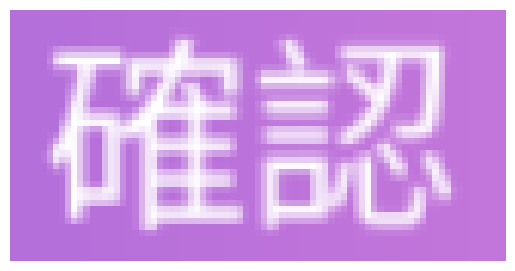

In [26]:
import cv2
import adbutils
import matplotlib.pyplot as plt
import os

# ================================
#  強制 ADB 重新撥號連線！
try:
    print("正在嘗試接通 ADB 橋樑...")
    adbutils.adb.connect("127.0.0.1:16384")
    print("ADB 橋樑接通成功！")
except Exception as e:
    print(f"ADB 連線有異常：{e}")

# ================================

my_device = adbutils.adb.device(serial="127.0.0.1:16384")

def capture_and_crop(save_name="target.png"):
    print("📸 正在擷取模擬器畫面...")
    my_device.screenshot().save("screen.png")
    img = cv2.imread("screen.png")
    
    # ==========================================
    # 🌟 新增的視窗控制魔法
    # ==========================================
    window_name = "Crop Tool (Press ENTER to save, C to cancel)"
    
    # 1. 建立一個「可以自由縮放」的視窗 (WINDOW_NORMAL 是關鍵)
    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)
    
    # 2. 取得原圖的長寬，用來等比例縮小視窗
    h, w = img.shape[:2]
    
    # 3. 設定你想要的視窗寬度 (800通常適合大部分筆電，你也可以改成 1024 或 1280)
    display_width = 1024
    display_height = int(h * (display_width / w)) # 等比例計算高度
    
    # 4. 強制把彈出來的視窗設定成這個大小
    cv2.resizeWindow(window_name, display_width, display_height)
    # ==========================================

    print("\n" + "="*40)
    print("裁切視窗已彈出！")
    print(f"視窗已自動縮小至 {display_width}x{display_height} 方便瀏覽。")
    print("你現在可以用滑鼠拖曳視窗邊緣，自由改變視窗大小了！")
    print("="*40 + "\n")

    # 把我們剛剛設定好大小的 window_name 傳進去
    roi = cv2.selectROI(window_name, img, showCrosshair=True, fromCenter=False)
    
    cv2.destroyAllWindows()

    x, y, w_roi, h_roi = roi
    
    if w_roi > 0 and h_roi > 0:
        crop_img = img[y:y+h_roi, x:x+w_roi]
        cv2.imwrite(os.path.join("images", save_name), crop_img)
        print(f"成功儲存小圖：{save_name} (真實原始解析度: {w_roi}x{h_roi} 像素)")
        
        crop_rgb = cv2.cvtColor(crop_img, cv2.COLOR_BGR2RGB)
        plt.imshow(crop_rgb)
        plt.axis('off')
        plt.show()
    else:
        print("❌ 取消裁切，沒有儲存任何圖片。")

# 測試看看！現在彈出來的視窗應該會剛剛好塞進你的螢幕裡了！
capture_and_crop("battle_victory.png")